In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [ ]:
df=pd.read_csv("Unemployment in India.csv")

In [ ]:
#basic checks

In [ ]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [ ]:
df.tail()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
763,NaN,NaN,NaN,NaN,NaN,NaN,NaN
764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
766,NaN,NaN,NaN,NaN,NaN,NaN,NaN
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df.shape

(768, 7)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [ ]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


In [ ]:
df.dtypes

,0
Region,object
Date,object
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [ ]:
df.isnull().sum() #check null values

,0
Region,28
Date,28
Frequency,28
Estimated Unemployment Rate (%),28
Estimated Employed,28
Estimated Labour Participation Rate (%),28
Area,28


In [ ]:
df.columns

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
#removes the extra spaces of the columns
df.columns= df.columns.str.strip()

In [ ]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [ ]:
#convert numerical columns to numeric dtypes
numeric_cols=['Estimated Unemployment Rate (%)','Estimated Employed', 'Estimated Labour Participation Rate (%)']

for columns in numeric_cols:
  df[columns]=pd.to_numeric(df[columns],errors='coerce')

In [ ]:
df.dtypes

,0
Region,object
Date,object
Frequency,object
Estimated Unemployment Rate (%),float64
Estimated Employed,float64
Estimated Labour Participation Rate (%),float64
Area,object


In [ ]:
#convert date to datetime format
df['Date']=pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

In [ ]:
df['Date'].dtype

dtype('<M8[ns]')

In [ ]:
#handle missing values
#fill the missing numerical values

for columns in numeric_cols:
  df[columns]=df[columns].fillna(df[columns].median())

In [ ]:
#fill the missing categorical values with the mode
df['Region']=df['Region'].fillna(df['Region'].mode()[0])
df['Frequency']=df['Frequency'].fillna(df['Frequency'].mode()[0])
df['Area']=df['Area'].fillna(df['Area'].mode()[0])

In [ ]:
#drop rows where the date is missing
df=df.dropna(subset=['Date'])

In [ ]:
df.isnull().sum()

,0
Region,0
Date,0
Frequency,0
Estimated Unemployment Rate (%),0
Estimated Employed,0
Estimated Labour Participation Rate (%),0
Area,0


In [ ]:
#calculate the average umemployment rate for each region
region_avg=df.groupby('Region')["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

In [ ]:
region_avg

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


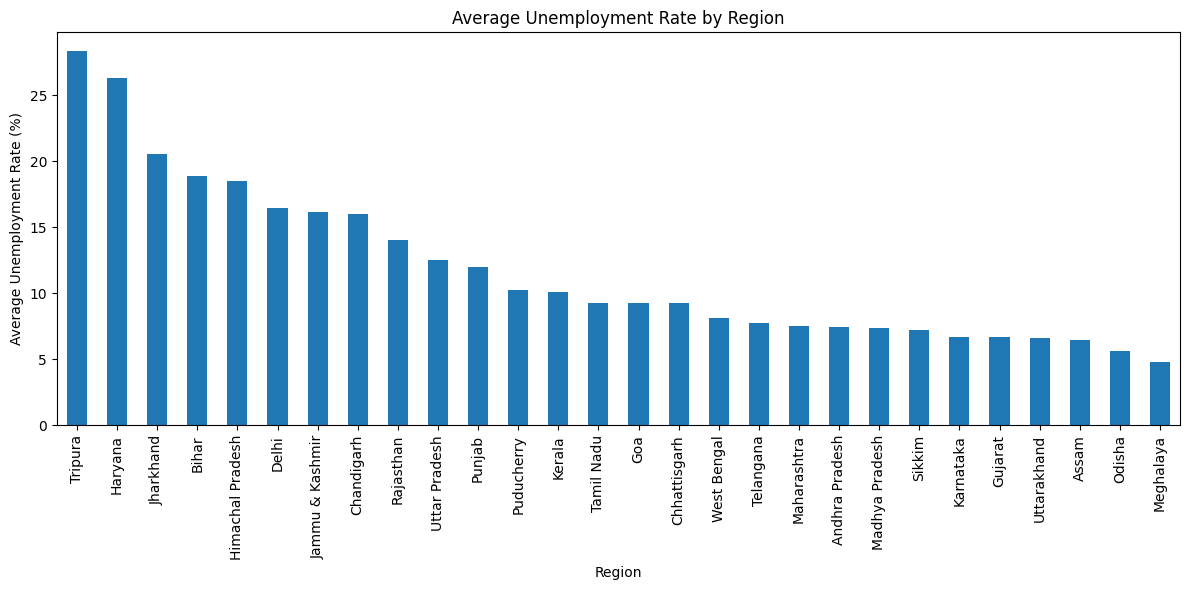

In [ ]:
#Visualize Regional Average Unemployment
plt.figure(figsize=(12,6))

region_avg.plot(kind='bar')
plt.title('Average Unemployment Rate by Region')
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=90)
plt.tight_layout()

### Observation

This bar chart compares the average unemployment rate across different
regions. Regions with taller bars have higher average unemployment rates,
while shorter bars represent lower average unemployment rates.

In [ ]:
#Month-wise Unemployment Trends

# Extract month names from the Date column
df['Month']=df['Date'].dt.month_name()

#calculate average unemployment rate by month
month_avg=df.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

In [ ]:
month_avg

,Estimated Unemployment Rate (%)
Month,
April,23.641569
August,9.637925
December,9.497358
February,9.964717
January,9.950755
July,9.033889
June,10.553462
March,10.700577
May,16.646190


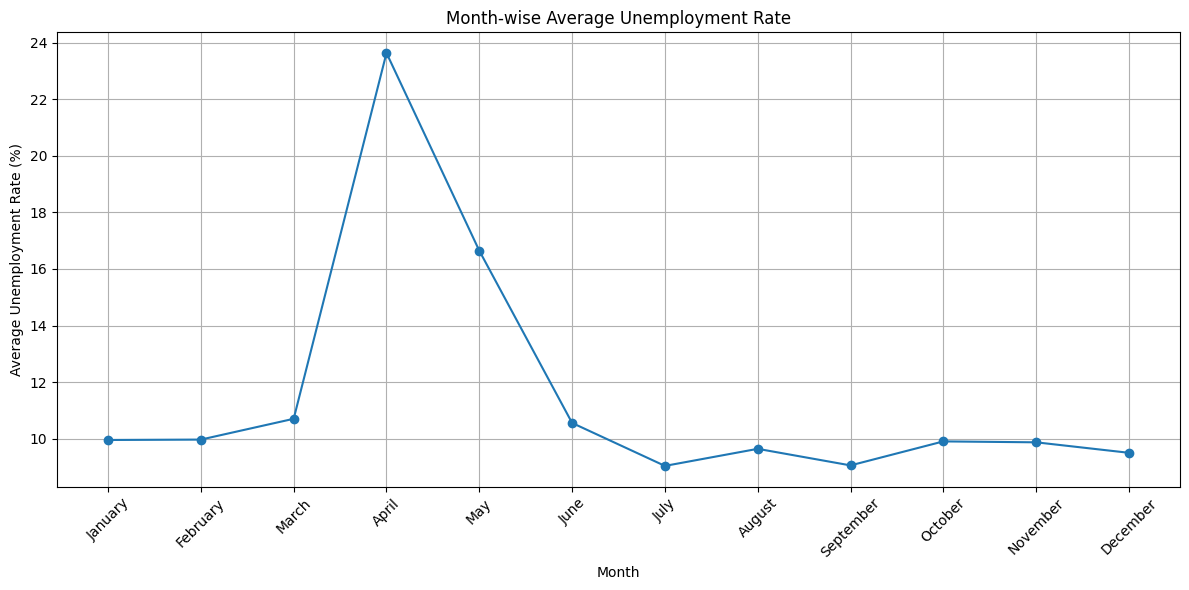

In [ ]:
#create a Month-wise Line Chart
month_order=["January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"]

# reorder the monthly averages
month_avg=month_avg.reindex(month_order)

# plot the monthly unemployment trend
plt.figure(figsize=(12,6))
plt.plot(month_avg.index, month_avg.values, marker='o')
plt.title("Month-wise Average Unemployment Rate")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

### Observation

The monthly trend shows that the average unemployment rate was highest
in April and May. This increase may be associated with the economic
disruptions caused by COVID-19-related restrictions. Unemployment rates were comparatively lower during the other months.

In [ ]:
df['Region'].unique()

array(['Andhra Pradesh', 'Assam', 'Bihar', 'Chhattisgarh', 'Delhi', 'Goa',
       'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu & Kashmir',
       'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh',
       'Maharashtra', 'Meghalaya', 'Odisha', 'Puducherry', 'Punjab',
       'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura',
       'Uttar Pradesh', 'Uttarakhand', 'West Bengal', 'Chandigarh'],
      dtype=object)

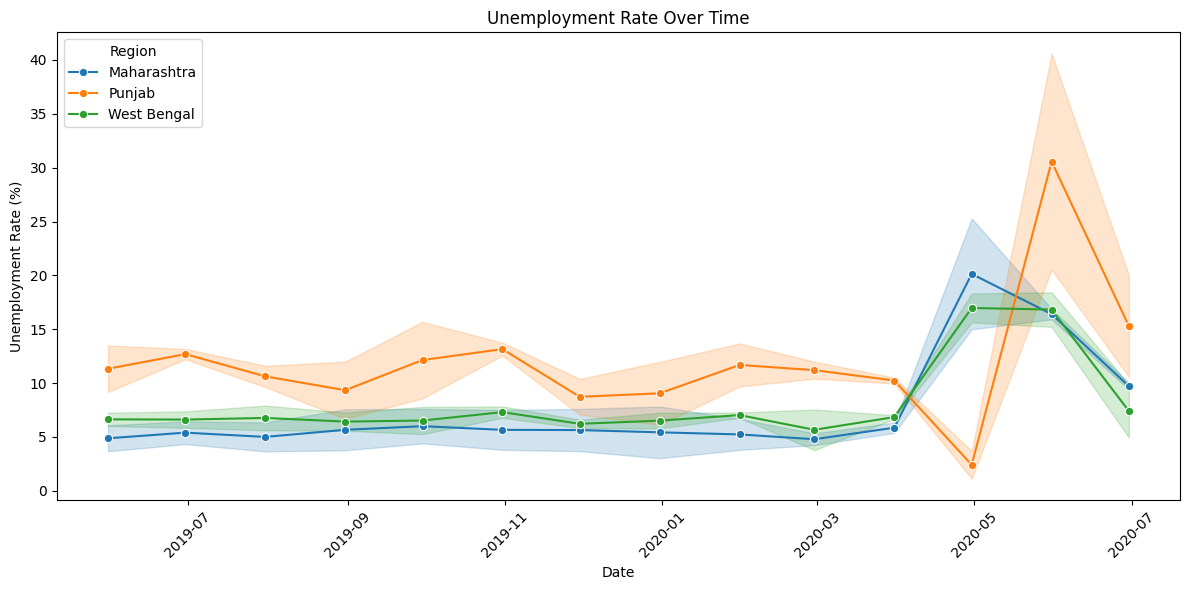

In [ ]:
#Time-Series Line Chart for 3 Major Regions

# Select three regions
selected_regions = ["Punjab", "Maharashtra", "West Bengal"]

# Filter the dataset
selected_df = df[df["Region"].isin(selected_regions)]

# Create the line chart
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=selected_df,
    x="Date",
    y="Estimated Unemployment Rate (%)",
    hue="Region",
    marker="o"
)

plt.title("Unemployment Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.legend(title="Region")
plt.tight_layout()
plt.show()

### Observation

The line chart shows how unemployment rates changed over time in
Punjab, Maharashtra, and West Bengal. The three regions show different
patterns and fluctuations in unemployment. A noticeable increase around
the COVID-19 period can be observed in the affected regions, although
the magnitude of the change differs between regions.

In [ ]:
#Top 10 Regions with Highest Average Unemployment

top_10_regions=region_avg.head(10)
top_10_regions

,Estimated Unemployment Rate (%)
Region,
Tripura,28.350357
Haryana,26.283214
Jharkhand,20.585000
Bihar,18.918214
Himachal Pradesh,18.540357
Delhi,16.495357
Jammu & Kashmir,16.188571
Chandigarh,15.991667
Rajasthan,14.058214


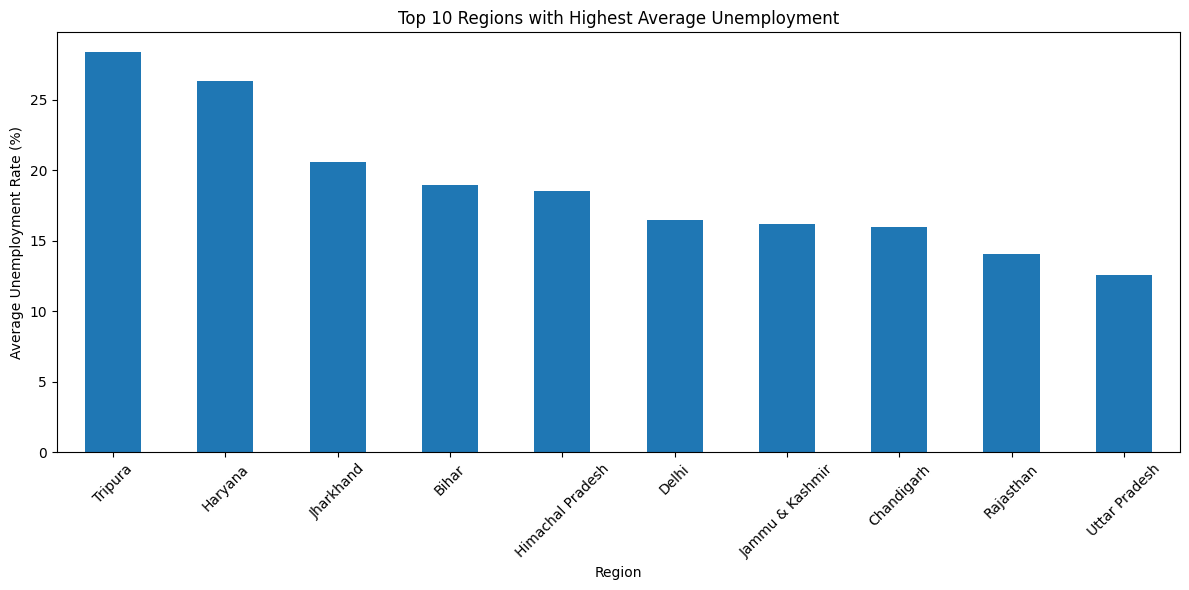

In [ ]:
plt.figure(figsize=(12,6))
top_10_regions.plot(kind='bar')
plt.title('Top 10 Regions with Highest Average Unemployment')
plt.xlabel('Region')
plt.ylabel('Average Unemployment Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()

### Observation

The bar chart shows the 10 regions with the highest average unemployment
rates in the dataset. The height of each bar represents the average
unemployment rate for that region. This helps identify regions that
experienced relatively higher unemployment during the period covered by
the dataset.

In [ ]:
#correlation heatmap
corr_data=df[["Estimated Unemployment Rate (%)",
        "Estimated Employed",
        "Estimated Labour Participation Rate (%)"]]

# Calculate the correlation matrix
correlation_matrix = corr_data.corr()
correlation_matrix

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
Estimated Unemployment Rate (%),1.000000,-0.222876,0.002558
Estimated Employed,-0.222876,1.000000,0.011300
Estimated Labour Participation Rate (%),0.002558,0.011300,1.000000


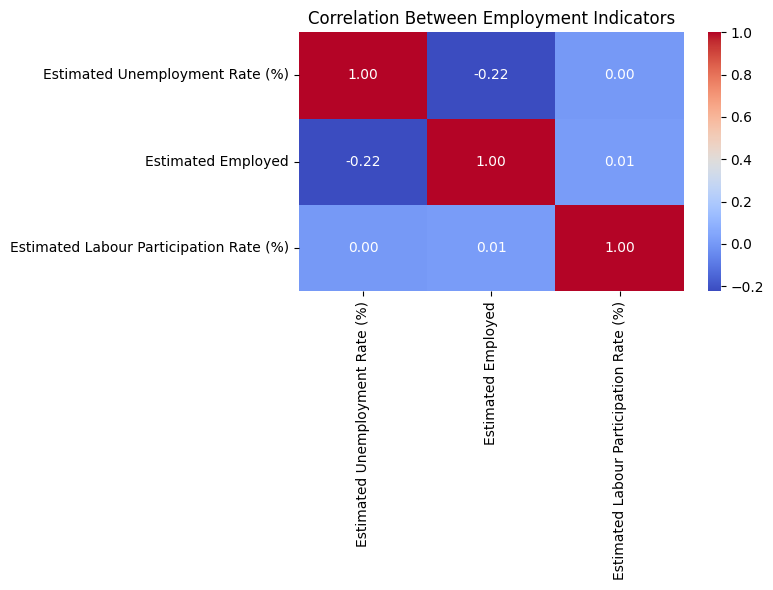

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=True, fmt='.2f')
plt.title('Correlation Between Employment Indicators')
plt.tight_layout()

The correlation values range from -1 to +1:

+1 = strong positive relationship

0 = little/no linear relationship

-1 = strong negative relationship

### Observation

The heatmap shows the correlation between unemployment, employment, and
labour participation.

The unemployment rate has a weak negative correlation with the estimated
number of employed people (-0.22). This means that, in this dataset,
higher unemployment rates are slightly associated with lower employment
levels.

The correlation between unemployment rate and labour participation rate
is approximately 0.00, indicating almost no linear relationship.

The correlation between estimated employment and labour participation
rate is also very weak (0.01).

Correlation shows association, not causation.

In [ ]:
#Pre-COVID vs Post-COVID comparison

# define the COVID-19 cutoff date
covid_date=pd.Timestamp('2020-03-01')

# create a new column identifying the period
df['Period']=np.where(
    df['Date'] < covid_date,
    'Pre_COVID',
    'Post_COVID'
)
# check how many records are in each period
df["Period"].value_counts()


,count
Period,
Pre_COVID,536
Post_COVID,204


In [ ]:
# calculate the average unemployment rate for each period

period_avg=df.groupby('Period')[
    'Estimated Unemployment Rate (%)'
].mean()
period_avg

,Estimated Unemployment Rate (%)
Period,
Post_COVID,17.774363
Pre_COVID,9.509534


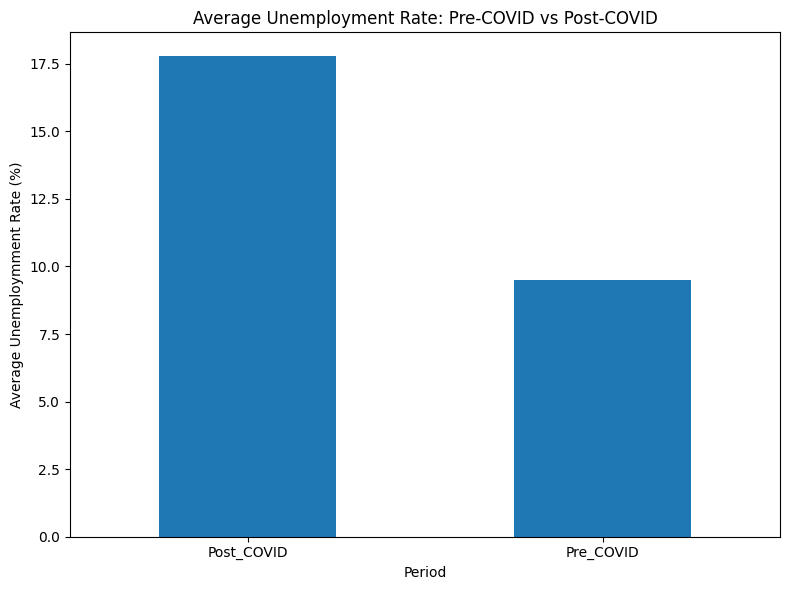

In [ ]:
#comparison chart

plt.figure(figsize=(8,6))
period_avg.plot(kind='bar')
plt.title('Average Unemployment Rate: Pre-COVID vs Post-COVID')
plt.xlabel('Period')
plt.ylabel('Average Unemploymment Rate (%)')
plt.xticks(rotation=0)
plt.tight_layout()

### Observation

The average unemployment rate was approximately 9.51% during the
Pre-COVID period and increased to approximately 17.77% during the
Post-COVID period.

This represents an increase of about 8.26 percentage points. The
dataset therefore shows substantially higher unemployment during the
Post-COVID period.

This comparison describes an association in the dataset and does not
by itself establish that COVID-19 caused the increase.

# **Conclusion**
The unemployment analysis examined regional and temporal patterns in
India's unemployment data.

The region-wise analysis showed that average unemployment rates varied
across regions. The month-wise analysis showed noticeable fluctuations,
with April and May having particularly high average unemployment rates.

The time-series analysis of selected regions showed that unemployment
rates changed over time and that the pattern varied between regions.

The correlation analysis showed a weak negative relationship between
unemployment rate and estimated employment (-0.22), while the
relationships involving labour participation rate were very weak.

The Pre-COVID vs Post-COVID comparison showed that the average
unemployment rate increased from approximately 9.51% in the Pre-COVID
period to approximately 17.77% in the Post-COVID period, an increase of
about 8.26 percentage points.

Overall, the analysis highlights substantial regional and temporal
variation in unemployment and a higher average unemployment rate during
the Post-COVID period. These findings describe patterns in the dataset
and should not be interpreted as proof of causation.